# Gallstone Final Report
- **Group 18**
    - Timothy
    - Elmeri
    - Pony
    - Miguel
- **STAT 301**
- **Dec 6 2025**

## Introduction
#### Summary
- The dataset assigned to our group is about Gallstone Disease by Esen, Irfan, et al. It contains bioimpedance and laboratory data to develop machine learning models for predicting gallstone disease, which was served as an alternative diagnostic approach to traditional imaging techniques such as ultrasonography, CT, and MRI (Esen, Irfan, et al.). Specifically, the dataset contains 319 observations of which 161 are gallstone patients and 158 are healthy controls (Esen, Irfan, et al.). Furthermore, the dataset includes 38 variables with no missing values (Esen, Irfan, et al.), and their name, type, and description are given in the table below:

#### Research Focus
- The primary focus of our question will be inference. We want to understand and quantify the relationship between each predictor and the odds of having gallstones. Specifically, we aim to determine which predictors are statistically significantly associated with gallstone disease.

#### Research Question
- Which bioimpedance measurements and laboratory biomarkers are significantly associated with gallstone disease?

#### Source & Information
- This dataset originates from a prospective descriptive study conducted at the Internal Medicine Outpatient Clinic of Ankara VM Medical Park Hospital between June 2022 and June 2023 (Esen, Irfan, et al.) From an initial 454 participants, 134 individuals who had undergone gallbladder surgery were excluded, resulting in the final dataset of 319 observations of which 161 are gallstone patients and 158 are healthy controls (Esen, Irfan, et al.).
- **Citation**
    - Esen, Irfan, et al. "Gallstone." UCI Machine Learning Repository, 2024, https://doi.org/10.1097/md.0000000000037258.

## Methods and Results

### Data

In [7]:
# load required libraries
library(readxl)
library(tidyverse)
library(ggplot2)
library(reshape2)
library(patchwork)
library(broom)

# set plot size
options(repr.plot.width = 15, repr.plot.height = 12)

In [8]:
# Download the zip file containing the dataset
outer_zip <- tempfile(fileext = ".zip")
download.file(
  "https://archive.ics.uci.edu/static/public/1150/gallstone-1.zip",
  outer_zip,
  mode = "wb"
)

# Unzip the outer zip into tempdir
tmp <- tempdir()
unzip(outer_zip, exdir = tmp)

# Locate the inner ZIP (dataset-uci.zip)
inner_zip <- list.files(
  tmp,
  pattern = "dataset-uci\\.zip$",
  full.names = TRUE,
  recursive = TRUE
)
inner_zip <- inner_zip[1]

# Unzip the inner zip file
unzip(inner_zip, exdir = tmp)

# Locate the xlsx data file
xlsx_path <- list.files(
  tmp,
  pattern = "dataset-uci\\.xlsx$",
  full.names = TRUE,
  recursive = TRUE
)

xlsx_path <- xlsx_path[1]

# Read the Excel file
gallstone_data <- read_xlsx(xlsx_path)

head(gallstone_data)

Gallstone Status,Age,Gender,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Height,Weight,⋯,High Density Lipoprotein (HDL),Triglyceride,Aspartat Aminotransferaz (AST),Alanin Aminotransferaz (ALT),Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Hemoglobin (HGB),Vitamin D
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,50,0,0,0,0,0,0,185,92.8,⋯,40,134,20,22,87,0.82,112.47,0,16.0,33.0
0,47,0,1,0,0,0,0,176,94.5,⋯,43,103,14,13,46,0.87,107.10,0,14.4,25.0
0,61,0,0,0,0,0,0,171,91.1,⋯,43,69,18,14,66,1.25,65.51,0,16.2,30.2
0,41,0,0,0,0,0,0,168,67.7,⋯,59,53,20,12,34,1.02,94.10,0,15.4,35.4
0,42,0,0,0,0,0,0,178,89.6,⋯,30,326,27,54,71,0.82,112.47,0,16.8,40.6
0,96,0,0,0,0,0,0,155,49.0,⋯,30,65,13,13,60,1.46,43.74,0,11.0,45.8


#### About the data

The dataset contains clinical data collected from the Internal Medicine Outpatient Clinic of Ankara VM Medical Park Hospital. The data represent 319 individuals with 116 individuals diagnosed with gallstone disease. There are 38 features representing demographic, biological, and laboratory data.

Citation:

Esen, I., Arslan, H., Aktürk, S., Gülşen, M., Kültekin, N., & Özdemir, O. (2024). Gallstone [Dataset]. UCI Machine Learning Repository. https://doi.org/10.1097/md.0000000000037258.

| Variable Name | Type | Description | Number of Observations |
|---------------|------|-------------|------------------------|
| Gallstone Status | Binary | Gallstones present (0) or absent (1) | 319 |
| Age | Integer | Age of the person | 319 |
| Gender | Categorical | Gender of the person | 319 |
| Comorbidity | Categorical | Other diseases that the person has: 0 (No comorbidities present), 1 (One comorbid condition), 2 (Two comorbid conditions), 3 (Three or more comorbid conditions)| 319 |
| Coronary Artery Disease (CAD) | Binary | Cardiovascular disease: 0 (No), 1 (Yes)| 319 |
| Hypothyroidism | Binary | Underactive thyroid gland: 0 (No), 1 (Yes) | 319 |
| Hyperlipidemia | Binary | High levels of fat in the blood: 0 (No), 1 (Yes) | 319 |
| Diabetes Mellitus (DM) | Binary | High blood sugar: 0 (No), 1 (Yes) | 319 |
| Height | Integer | Height in cm | 319|
| Weight | Numeric | Weight in kg | 319|
| Body Mass Index (BMI) | Numeric | Weight to height ratio | 319 |
| Total Body Water (TBW) | Numeric | Total water in the body | 319 |
| Extracellular Water (ECW) | Numeric | Extracellular water | 319 |
| Intracellular Water (ICW) | Numeric | Intracellular water | 319 |
| Extracellular Fluid/Total Body Water (ECF/TBW) | Numeric | Extracellular water content | 319 |
| Total Body Fat Ratio (TBFR) (%) | Numeric | Total fat content (%) | 319 |
| Lean Mass (LM) (%) | Numeric | Lean body mass (%) | 319 |
| Body Protein Content (Protein) (%) | Numeric | Body protein content (%) | 319 |
| Visceral Fat Rating (VFR) | Integer | Visceral organ fat level | 319 |
| Bone Mass (BM) | Numeric | Mass of bones | 319 |
| Muscle Mass (MM) | Numeric | Muscle mass | 319 |
| Obesity (%) | Numeric | Excess fat (%) | 319 |
| Total Fat Content (TFC) | Numeric | Total fat amount | 319 |
| Visceral Fat Area (VFA) | Numeric | Inner adipose tissue area | 319 |
| Visceral Muscle Area (VMA) (Kg) | Numeric | Inner muscle area (kg) | 319 |
| Hepatic Fat Accumulation (HFA) | Categorical | Accumulation of fat in the liver: 0 (No fat accumulation),1 (Grade 1 (mild)), 2 (Grade 2 (moderate)), 3 (Grade 3 (severe)), 4 (Grade 4 (very severe)) | 319 |
| Glucose | Numeric | Blood sugar | 319 |
| Total Cholesterol (TC) | Numeric | Total cholesterol amount | 319 |
| Low Density Lipoprotein (LDL) | Numeric | Amount of "bad" cholesterol | 319 |
| High Density Lipoprotein (HDL) | Numeric | Amount of "good" cholesterol | 319 |
| Triglyceride | Numeric | Amount of trigliceride fats found in blood | 319 |
| Aspartate Aminotransferase (AST) | Numeric | Amount of liver enzyme | 319 |
| Alanine Aminotransferase (ALT) | Numeric | Amount of liver enzyme | 319 |
| Alkaline Phosphatase (ALP) | Numeric | Amount of liver and bone enzyme | 319 |
| Creatinine | Numeric | Kidney function indicator | 319 |
| Glomerular Filtration Rate (GFR) | Numeric | Kidney filtration rate | 319 |
| C-Reactive Protein (CRP) | Numeric | Inflammation indicator | 319 |
| Hemoglobin (HGB) | Numeric | Protein that carries oxygen in the blood | 319 |
| Vitamin D | Numeric | Essential vitamin for bone health | 319 |

#### Variable Selection
- Response
  - Gallstone status

- Predictors of interest
  - Lipid panel: TC, LDL, HDL, Triglyceride
  - Liver enzymes: AST, ALT, ALP
  - Blood lab: CRP, Creatinine or GFR, HGB, Vitamin D
  - Age, Sex

- Exclusions
  - Other body-composition/comorbidity variables to keep the analysis focused

### Exploratory Data Analysis

In [10]:
exploratory_data <- gallstone_data %>%
    select(`Gallstone Status`, Age, Gender, `High Density Lipoprotein (HDL)`, `Low Density Lipoprotein (LDL)`,
  `Total Cholesterol (TC)`, `Triglyceride`, `Aspartat Aminotransferaz (AST)`, `Alanin Aminotransferaz (ALT)`,
  `Alkaline Phosphatase (ALP)`, Creatinine, `Glomerular Filtration Rate (GFR)`, `C-Reactive Protein (CRP)`,
  `Hemoglobin (HGB)`, `Vitamin D`)

# rename columns for easier reference
colnames(exploratory_data) <- c("gallstone_status", "age", "sex", "hdl", "ldl", "tc", "triglyceride", "ast",
                                "alt", "alp", "creatinine", "gfr", "crp", "hgb", "vit_d")

# recode binary variables as factors
exploratory_data$gallstone_status <- factor(exploratory_data$gallstone_status,
                                    levels = 0:1,
                                    labels = c("Yes", "No"))

# recode gender variable as factor
exploratory_data$sex <- factor(exploratory_data$sex,
                            levels = 0:1,
                            labels = c("M", "F"))

head(exploratory_data)

gallstone_status,age,sex,hdl,ldl,tc,triglyceride,ast,alt,alp,creatinine,gfr,crp,hgb,vit_d
<fct>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Yes,50,M,40,175,250,134,20,22,87,0.82,112.47,0,16.0,33.0
Yes,47,M,43,108,172,103,14,13,46,0.87,107.10,0,14.4,25.0
Yes,61,M,43,124,179,69,18,14,66,1.25,65.51,0,16.2,30.2
Yes,41,M,59,73,173,53,20,12,34,1.02,94.10,0,15.4,35.4
Yes,42,M,30,154,205,326,27,54,71,0.82,112.47,0,16.8,40.6
Yes,96,M,30,91,133,65,13,13,60,1.46,43.74,0,11.0,45.8


In [11]:
# show summary of the data
summary(exploratory_data)

 gallstone_status      age        sex          hdl              ldl       
 Yes:161          Min.   :20.00   M:162   Min.   : 25.00   Min.   : 11.0  
 No :158          1st Qu.:38.50   F:157   1st Qu.: 40.00   1st Qu.:100.5  
                  Median :49.00           Median : 46.50   Median :122.0  
                  Mean   :48.07           Mean   : 49.48   Mean   :126.7  
                  3rd Qu.:56.00           3rd Qu.: 56.00   3rd Qu.:151.0  
                  Max.   :96.00           Max.   :273.00   Max.   :293.0  
       tc         triglyceride         ast              alt        
 Min.   : 60.0   Min.   :  1.39   Min.   :  8.00   Min.   :  3.00  
 1st Qu.:172.0   1st Qu.: 83.00   1st Qu.: 15.00   1st Qu.: 14.25  
 Median :198.0   Median :119.00   Median : 18.00   Median : 19.00  
 Mean   :203.5   Mean   :144.50   Mean   : 21.68   Mean   : 26.86  
 3rd Qu.:233.0   3rd Qu.:172.00   3rd Qu.: 23.00   3rd Qu.: 30.00  
 Max.   :360.0   Max.   :838.00   Max.   :195.00   Max.   :372.00  

In [12]:
# create boxplots for each predictor by gallstone status
boxplots <- exploratory_data %>%
  pivot_longer(cols = -c(gallstone_status, age, sex), names_to = "predictor", values_to = "value") %>%
  ggplot(aes(x = gallstone_status, y = value, fill = gallstone_status)) +
  geom_boxplot() +
  facet_wrap(~ predictor, scales = "free") +
  labs(x = NULL, y = "Value", fill = "Gallstone Status") +
  ggtitle("Boxplots of Predictors by Gallstone Status")

In [13]:
# create a plot of age distribution by sex and gallstone status
age_sex_plot <- exploratory_data %>%
  ggplot(aes(x = age, fill = gallstone_status)) +
  geom_density(alpha=0.5) +
  facet_wrap(~ sex) +
  labs(x = "Age", y = "Count", fill = "Gallstone Status") +
  ggtitle("Age Distribution by sex and gallstone status")

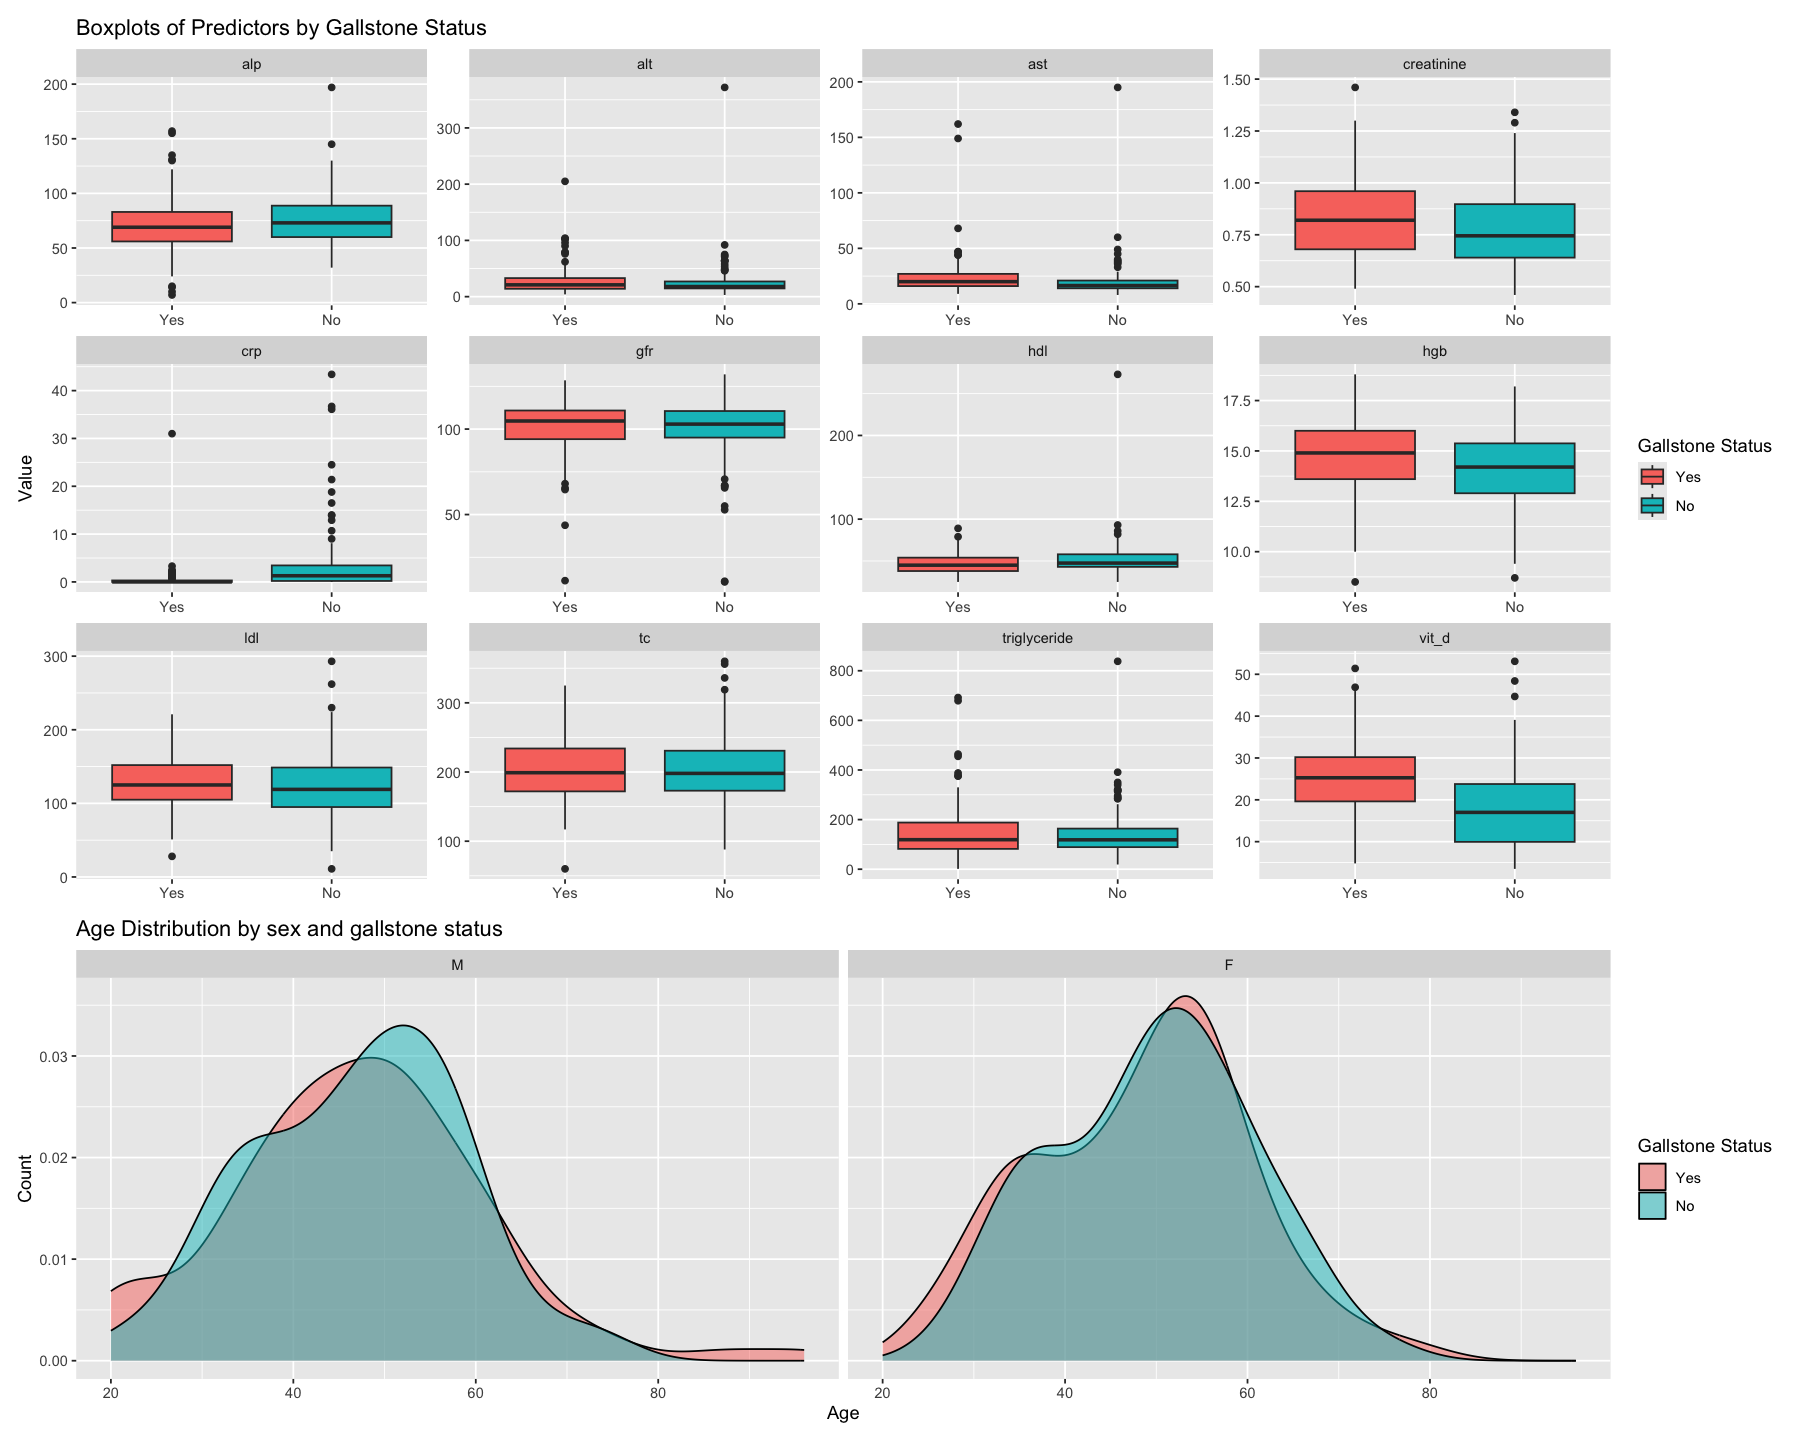

In [14]:
# generate a composite figure using the two previous plots
fig <- wrap_plots(boxplots, age_sex_plot, 
           ncol = 1, nrow = 2,
           widths = c(1, 1), heights = c(1, 0.5))

fig

The boxplots above show the distribution and spread of each continuous predictor by gallstone status. Boxplots are useful for comparing distributions between groups because they clearly display medians, quartiles, and outliers, making it easy to identify potential associations and detect skewness that might require transformation.

The density plots for age show smooth, overlapping distributions by gallstone status within each sex group. These plots can be usedto compare distribution shapes and peaks between overlapping groups to assess whether age distributions differ by gallstone status and sex.

The boxplots above illustrate the distribution of different numeric variables by gallstone status. From the boxplots we can see that most of the selected variables have similar distributions between the two gallstone groups. A few exceptions are the liver enzymes AST/ALT/ALP, creatinine, C-reactive protein (CRP), Hemoglobin (HGB), and vitamin-D, so these may be associated with gallstone status. The liver enzymes, CRP, HDL, and trigliceride are skewed with outliers, so a log transform may be needed to interpret these better. 

The histograms show the distribution of age by gallstone status and sex. The age distributions are very similar between the 2 gallstone status groups for both males and females, suggesting that age may not be a factor in gallstone status on its own. The most common age for patients in the dataset is between 50-60 years old. There seem to be two different peaks within the age distributions, so it may be worthwhile to group the ages (e.g. <=50 and >50).